<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 77.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 78.1 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


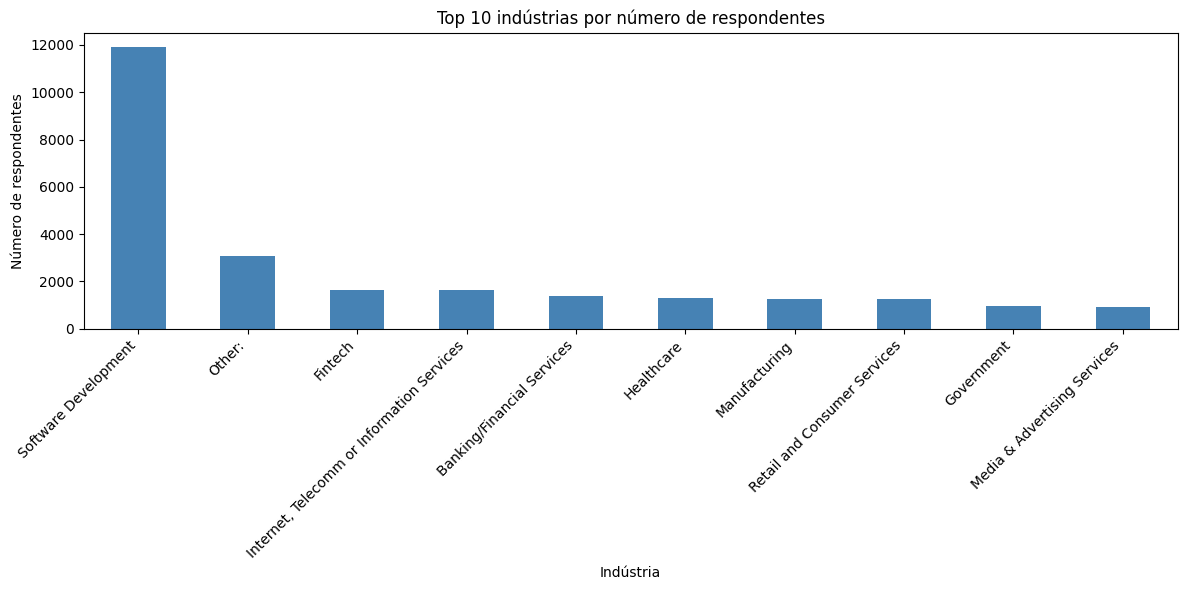

In [3]:
top_industries = df['Industry'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_industries.plot(kind='bar', color='steelblue')
plt.title('Top 10 indústrias por número de respondentes')
plt.xlabel('Indústria')
plt.ylabel('Número de respondentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
# Estatísticas básicas
media = df['ConvertedCompYearly'].mean()
mediana = df['ConvertedCompYearly'].median()
desvio = df['ConvertedCompYearly'].std()

print(f"Média:          ${media:,.2f}")
print(f"Mediana:        ${mediana:,.2f}")
print(f"Desvio padrão:  ${desvio:,.2f}")

# Limite: 3 desvios padrão acima da média
limite_superior = media + 3 * desvio
print(f"\nLimite superior (média + 3σ): ${limite_superior:,.2f}")

# Identificar outliers
outliers_std = df[df['ConvertedCompYearly'] > limite_superior]
print(f"Outliers encontrados: {len(outliers_std)}")
print(outliers_std['ConvertedCompYearly'].describe())

Média:          $86,155.29
Mediana:        $65,000.00
Desvio padrão:  $186,756.97

Limite superior (média + 3σ): $646,426.21
Outliers encontrados: 89
count    8.900000e+01
mean     1.623895e+06
std      2.366560e+06
min      6.500000e+05
25%      7.500000e+05
50%      1.000000e+06
75%      1.332930e+06
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25%): $32,712.00
Q3 (75%): $107,971.50
IQR:      $75,259.50

Limite inferior: $-80,177.25
Limite superior: $220,860.75

Outliers pelo IQR: 978


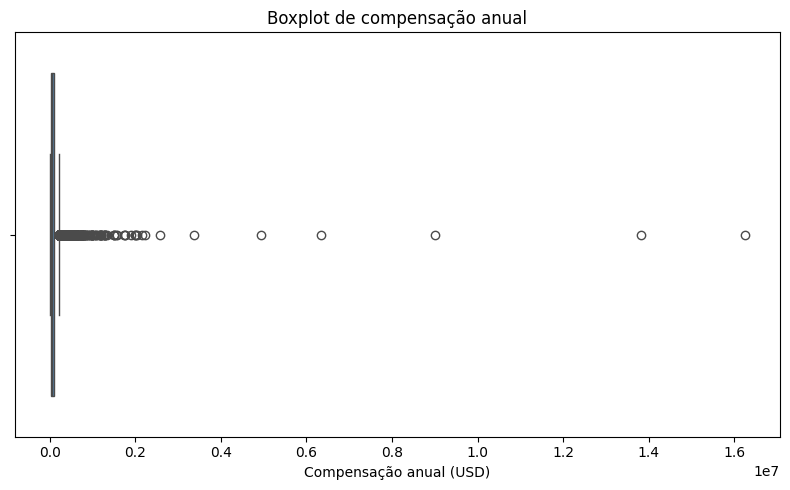

In [5]:
# Calcular IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25%): ${Q1:,.2f}")
print(f"Q3 (75%): ${Q3:,.2f}")
print(f"IQR:      ${IQR:,.2f}")

# Limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior_iqr = Q3 + 1.5 * IQR

print(f"\nLimite inferior: ${limite_inferior:,.2f}")
print(f"Limite superior: ${limite_superior_iqr:,.2f}")

# Contar outliers
outliers_iqr = df[(df['ConvertedCompYearly'] < limite_inferior) | 
                   (df['ConvertedCompYearly'] > limite_superior_iqr)]
print(f"\nOutliers pelo IQR: {len(outliers_iqr)}")

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ConvertedCompYearly'].dropna(), color='steelblue')
plt.title('Boxplot de compensação anual')
plt.xlabel('Compensação anual (USD)')
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [6]:
# Criar novo DataFrame sem outliers
df_clean = df[(df['ConvertedCompYearly'] >= limite_inferior) & 
              (df['ConvertedCompYearly'] <= limite_superior_iqr)]

print(f"Linhas originais:      {len(df)}")
print(f"Linhas sem outliers:   {len(df_clean)}")
print(f"Outliers removidos:    {len(df) - len(df_clean)}")

# Comparar estatísticas antes e depois
print("\nAntes da remoção:")
print(df['ConvertedCompYearly'].describe())
print("\nDepois da remoção:")
print(df_clean['ConvertedCompYearly'].describe())

Linhas originais:      65437
Linhas sem outliers:   22457
Outliers removidos:    42980

Antes da remoção:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Depois da remoção:
count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


                      Age_num  YearsCodePro  ConvertedCompYearly   WorkExp  \
Age_num              1.000000      0.822447             0.369666  0.845965   
YearsCodePro         0.822447      1.000000             0.387209  0.923855   
ConvertedCompYearly  0.369666      0.387209             1.000000  0.408438   
WorkExp              0.845965      0.923855             0.408438  1.000000   
JobSatPoints_1      -0.039209     -0.037566            -0.058170 -0.032388   

                     JobSatPoints_1  
Age_num                   -0.039209  
YearsCodePro              -0.037566  
ConvertedCompYearly       -0.058170  
WorkExp                   -0.032388  
JobSatPoints_1             1.000000  


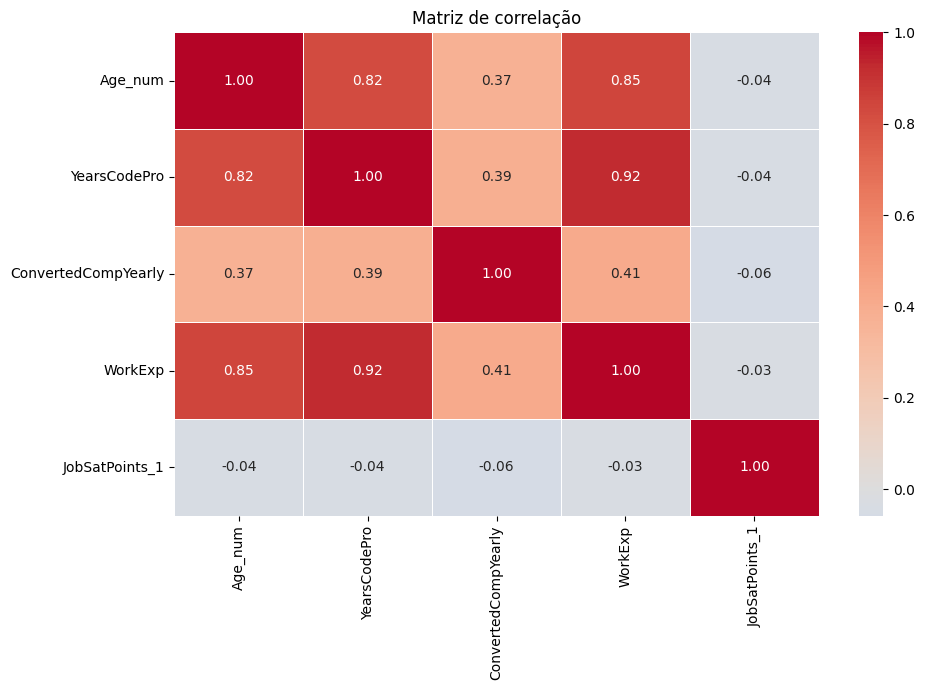

In [7]:
# Mapear Age para valores numéricos
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 65,
    'Prefer not to say': None
}

df_clean = df_clean.copy()
df_clean['Age_num'] = df_clean['Age'].map(age_map)

# Selecionar colunas numéricas para correlação
cols_numericas = ['Age_num', 'YearsCodePro', 'ConvertedCompYearly', 
                  'WorkExp', 'JobSatPoints_1']
df_corr = df_clean[cols_numericas].apply(pd.to_numeric, errors='coerce')

# Matriz de correlação
corr_matrix = df_corr.corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
